# 1.Load & check Dataset

In [1]:
import pandas as pd
import numpy as np

In [2]:
train_df = pd.read_csv("train_data.csv")
valid_df = pd.read_csv("valid_data.csv")

In [3]:
train_df.shape

(16990, 2)

In [4]:
valid_df.shape

(4117, 2)

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16990 entries, 0 to 16989
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    16990 non-null  object
 1   label   16990 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 265.6+ KB


In [6]:
train_df.head()

,text,label
0,Here are Thursday's biggest analyst calls: App...,0
1,Buy Las Vegas Sands as travel to Singapore bui...,0
2,"Piper Sandler downgrades DocuSign to sell, cit...",0
3,"Analysts react to Tesla's latest earnings, bre...",0
4,Netflix and its peers are set for a ‘return to...,0


In [7]:
train_df.isnull().sum()

text     0
label    0
dtype: int64

In [8]:
train_df["label"].nunique()

20

In [9]:
train_df["label"].value_counts()

label
2     3545
18    2118
14    1822
9     1557
5      987
16     985
1      837
19     823
7      624
6      524
15     501
17     495
12     487
13     471
4      359
3      321
0      255
8      166
10      69
11      44
Name: count, dtype: int64

In [10]:
#checking random tweets 
train_df.sample(5)

,text,label
2661,$CLVR $INCR - Clever Leaves exports cannabis t...,2
9467,$ABB: ABB Ltd to spin off its Accelleron turbo...,13
16232,"$CLVR $RCM $NEXI - NexImmune, Allogene top hea...",19
14675,Beat flagging $SPY $SPX $ES_F https://t.co/aV...,18
1174,Skydance Media and Mattel to Develop Matchbox ...,2


# 2.Data Cleaning 

In [11]:
import re
import nltk
from nltk.corpus import stopwords

In [12]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
#Check Tweet Before Cleaning
train_df["text"].iloc[0]

"Here are Thursday's biggest analyst calls: Apple, Amazon, Tesla, Palantir, DocuSign, Exxon &amp; more  https://t.co/QPN8Gwl7Uh"

In [14]:
#Create Cleaning Function
def clean_text(text):
    
    # remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    
    # remove punctuation
    text = re.sub(r"[^\w\s]", "", text)
    
    # remove numbers
    text = re.sub(r"\d+", "", text)
    
    # convert to lowercase
    text = text.lower()
    
    # remove extra spaces
    text = text.strip()
    
    return text

In [15]:
#Apply Cleaning to Dataset
train_df["clean_text"] = train_df["text"].apply(clean_text)
valid_df["clean_text"] = valid_df["text"].apply(clean_text)

In [16]:
train_df[["text","clean_text"]].head()

,text,clean_text
0,Here are Thursday's biggest analyst calls: App...,here are thursdays biggest analyst calls apple...
1,Buy Las Vegas Sands as travel to Singapore bui...,buy las vegas sands as travel to singapore bui...
2,"Piper Sandler downgrades DocuSign to sell, cit...",piper sandler downgrades docusign to sell citi...
3,"Analysts react to Tesla's latest earnings, bre...",analysts react to teslas latest earnings break...
4,Netflix and its peers are set for a ‘return to...,netflix and its peers are set for a return to ...


In [17]:
#Remove Stopwords (Stopwords are common words that do not add meaning).
stop_words = set(stopwords.words("english"))

In [18]:
def remove_stopwords(text):
    
    words = text.split()
    
    filtered_words = [word for word in words if word not in stop_words]
    
    return " ".join(filtered_words)

In [19]:
train_df["clean_text"] = train_df["clean_text"].apply(remove_stopwords)
valid_df["clean_text"] = valid_df["clean_text"].apply(remove_stopwords)

In [20]:
train_df[["text","clean_text"]].head()

,text,clean_text
0,Here are Thursday's biggest analyst calls: App...,thursdays biggest analyst calls apple amazon t...
1,Buy Las Vegas Sands as travel to Singapore bui...,buy las vegas sands travel singapore builds we...
2,"Piper Sandler downgrades DocuSign to sell, cit...",piper sandler downgrades docusign sell citing ...
3,"Analysts react to Tesla's latest earnings, bre...",analysts react teslas latest earnings break wh...
4,Netflix and its peers are set for a ‘return to...,netflix peers set return growth analysts say g...


In [21]:
train_df["clean_text"].isnull().sum()

np.int64(0)

In [22]:
#Check Random Clean Tweets
train_df["clean_text"].sample(5)

7487     new hes goodness heart sam bankmanfried yearol...
8709     bankinter says proposed tax spanish banks unfa...
11135    heres rents bedroom apartments increased past ...
10258    citigroup economists labeled global recession ...
16589    ttoo pre biosystems ttoo granted fda breakthro...
Name: clean_text, dtype: object

# 3.Exploratory Data Analysis (EDA)

In [23]:
import sys
!{sys.executable} -m pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [25]:
sns.set_style("whitegrid")

C:\Users\Admin\AppData\Local\Temp\ipykernel_11688\3000319725.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_df["label"], palette="viridis")


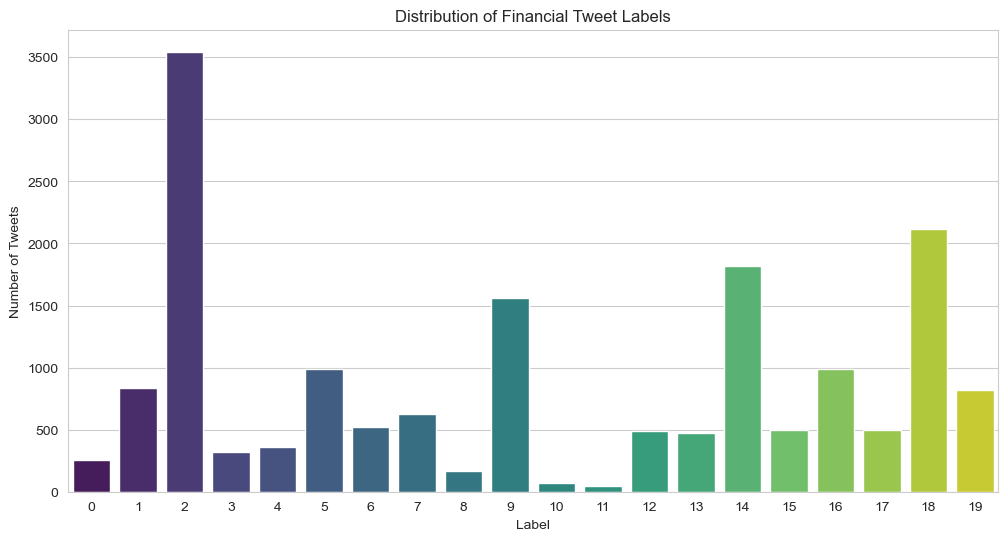

In [26]:
#Label Distribution
plt.figure(figsize=(12,6))
sns.countplot(x=train_df["label"], palette="viridis")

plt.title("Distribution of Financial Tweet Labels")
plt.xlabel("Label")
plt.ylabel("Number of Tweets")

plt.show()

In [27]:
#Check Dataset Imbalance
label_counts = train_df["label"].value_counts().sort_index()

print(label_counts)

label
0      255
1      837
2     3545
3      321
4      359
5      987
6      524
7      624
8      166
9     1557
10      69
11      44
12     487
13     471
14    1822
15     501
16     985
17     495
18    2118
19     823
Name: count, dtype: int64


In [28]:
label_mapping = {
0:"Analyst Update",
1:"Fed | Central Banks",
2:"Company | Product News",
3:"Treasuries | Corporate Debt",
4:"Dividend",
5:"Earnings",
6:"Energy | Oil",
7:"Financials",
8:"Currencies",
9:"General News | Opinion",
10:"Gold | Metals | Materials",
11:"IPO",
12:"Legal | Regulation",
13:"M&A | Investments",
14:"Macro",
15:"Markets",
16:"Politics",
17:"Personnel Change",
18:"Stock Commentary",
19:"Stock Movement"
}

train_df["topic"] = train_df["label"].map(label_mapping)

In [29]:
train_df[["clean_text","topic"]].head()

,clean_text,topic
0,thursdays biggest analyst calls apple amazon t...,Analyst Update
1,buy las vegas sands travel singapore builds we...,Analyst Update
2,piper sandler downgrades docusign sell citing ...,Analyst Update
3,analysts react teslas latest earnings break wh...,Analyst Update
4,netflix peers set return growth analysts say g...,Analyst Update


In [30]:
#Tweet Length Analysis
train_df["tweet_length"] = train_df["clean_text"].apply(len)

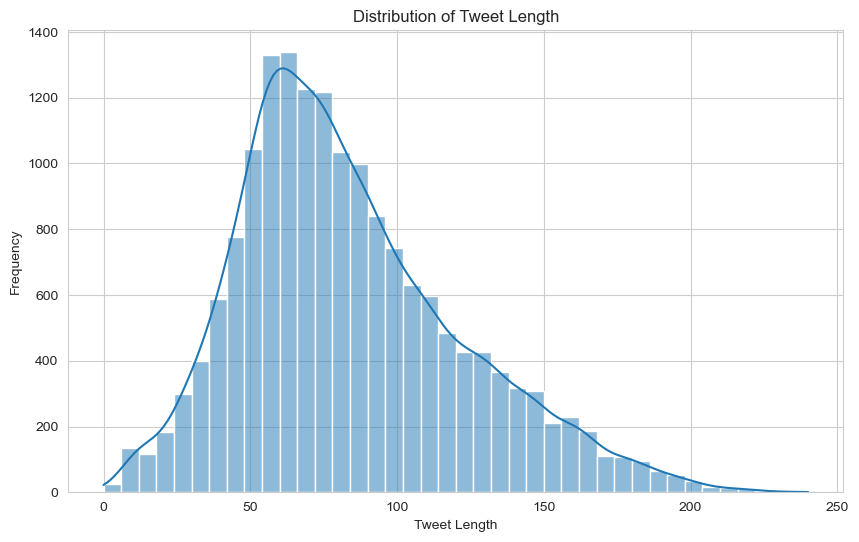

In [31]:
plt.figure(figsize=(10,6))

sns.histplot(train_df["tweet_length"], bins=40, kde=True)

plt.title("Distribution of Tweet Length")
plt.xlabel("Tweet Length")
plt.ylabel("Frequency")

plt.show()


##### Word Frequency Analysis

In [32]:
all_words = " ".join(train_df["clean_text"])

In [33]:
words = all_words.split()

In [34]:
from collections import Counter

word_freq = Counter(words)

In [35]:
word_freq.most_common(10)

[('us', 1321),
 ('new', 1117),
 ('earnings', 970),
 ('stocks', 895),
 ('economy', 852),
 ('inflation', 827),
 ('markets', 812),
 ('business', 779),
 ('q', 771),
 ('trading', 714)]

#### Word Cloud Visualization

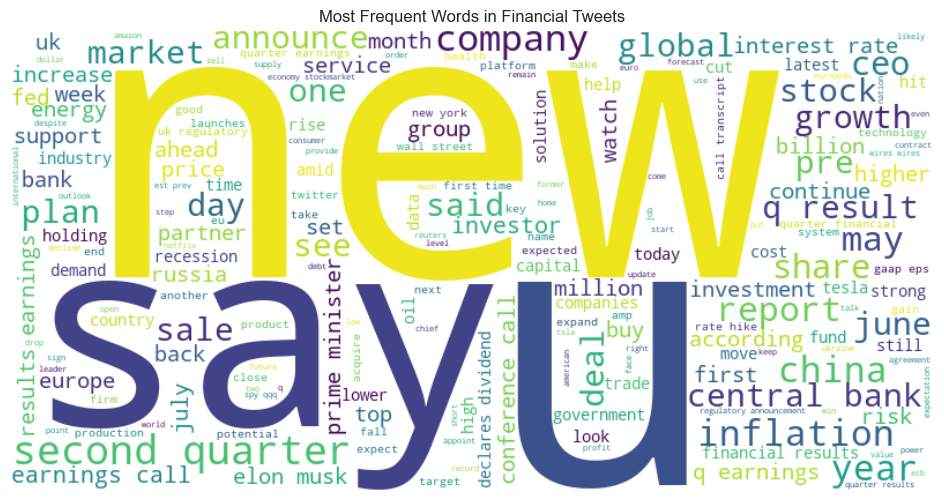

In [36]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_words)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Most Frequent Words in Financial Tweets")

plt.show()

In [37]:
#Average Tweet Length by Topic
topic_length = train_df.groupby("topic")["tweet_length"].mean().sort_values(ascending=False)

print(topic_length)

topic
Politics                       110.626396
Legal | Regulation             104.517454
Fed | Central Banks            100.953405
General News | Opinion          95.011561
Macro                           94.317234
IPO                             92.818182
Energy | Oil                    88.248092
Treasuries | Corporate Debt     85.034268
Currencies                      84.849398
M&A | Investments               82.520170
Company | Product News          82.182793
Markets                         80.596806
Analyst Update                  77.509804
Gold | Metals | Materials       76.101449
Earnings                        75.053698
Stock Movement                  74.249089
Personnel Change                70.078788
Stock Commentary                65.608121
Financials                      63.411859
Dividend                        55.245125
Name: tweet_length, dtype: float64


# 4.Convert Text to Numbers (TF-IDF) + Train ML Model

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [39]:
#Prepare Training and Validation Data
X_train = train_df["clean_text"]
y_train = train_df["label"]

X_valid = valid_df["clean_text"]
y_valid = valid_df["label"]

In [40]:
#Convert Text → TF-IDF Features
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_valid_tfidf = tfidf.transform(X_valid)

In [41]:
#Check Feature Matrix Shape
print(X_train_tfidf.shape)
print(X_valid_tfidf.shape)

(16990, 5000)
(4117, 5000)


### 4.1 Logistic Regression Model

In [42]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [43]:
y_pred = model.predict(X_valid_tfidf)

In [44]:
accuracy = accuracy_score(y_valid, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.7835802769006558


In [45]:
print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.47      0.63        73
           1       0.85      0.76      0.80       214
           2       0.69      0.91      0.79       852
           3       0.94      0.60      0.73        77
           4       0.99      0.90      0.94        97
           5       0.92      0.90      0.91       242
           6       0.82      0.75      0.78       146
           7       0.88      0.78      0.83       160
           8       0.92      0.34      0.50        32
           9       0.67      0.68      0.67       336
          10       0.29      0.15      0.20        13
          11       1.00      0.43      0.60        14
          12       0.97      0.58      0.73       119
          13       0.87      0.47      0.61       116
          14       0.73      0.82      0.77       415
          15       0.86      0.63      0.73       125
          16       0.92      0.83      0.87       249
          17       0.94    

In [46]:
sample_text = ["tesla stock jumps after strong earnings"]

sample_tfidf = tfidf.transform(sample_text)

prediction = model.predict(sample_tfidf)

print("Predicted Label:", prediction[0])

Predicted Label: 19


### 4.2 XGBoost Model Implementation 

In [47]:
import sys
!{sys.executable} -m pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [48]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [49]:
#Create XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    objective="multi:softmax",
    num_class=20,
    random_state=42
)

In [50]:
#Train the Model
xgb_model.fit(X_train_tfidf, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_class=20, ...)

In [51]:
#Make Predictions
xgb_pred = xgb_model.predict(X_valid_tfidf)

In [52]:
#Calculate Accuracy
xgb_accuracy = accuracy_score(y_valid, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.766820500364343


In [53]:
print(classification_report(y_valid, xgb_pred))

              precision    recall  f1-score   support

           0       0.88      0.58      0.69        73
           1       0.84      0.80      0.82       214
           2       0.62      0.87      0.72       852
           3       0.90      0.71      0.80        77
           4       0.96      0.97      0.96        97
           5       0.88      0.94      0.91       242
           6       0.77      0.82      0.79       146
           7       0.84      0.79      0.81       160
           8       0.84      0.81      0.83        32
           9       0.75      0.55      0.63       336
          10       0.62      0.62      0.62        13
          11       0.87      0.93      0.90        14
          12       0.94      0.73      0.82       119
          13       0.82      0.59      0.68       116
          14       0.79      0.73      0.76       415
          15       0.82      0.66      0.73       125
          16       0.89      0.80      0.84       249
          17       0.93    

### 4.3 Compare Both Models

In [54]:
print("Logistic Regression Accuracy:", accuracy)
print("XGBoost Accuracy:", xgb_accuracy)

Logistic Regression Accuracy: 0.7835802769006558
XGBoost Accuracy: 0.766820500364343


# 5.Sentiment Analysis Using VADER

In [55]:
import sys
!{sys.executable} -m pip install vaderSentiment

Defaulting to user installation because normal site-packages is not writeable


In [56]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [57]:
#Initialize Sentiment Analyzer
analyzer = SentimentIntensityAnalyzer()

In [58]:
#Create Sentiment Function
def get_sentiment(text):
    
    score = analyzer.polarity_scores(text)
    
    compound = score["compound"]
    
    if compound >= 0.05:
        return "Bullish"
    
    elif compound <= -0.05:
        return "Bearish"
    
    else:
        return "Neutral"

In [59]:
train_df["sentiment"] = train_df["clean_text"].apply(get_sentiment)

In [60]:
train_df[["clean_text","sentiment"]].head()

,clean_text,sentiment
0,thursdays biggest analyst calls apple amazon t...,Bullish
1,buy las vegas sands travel singapore builds we...,Bullish
2,piper sandler downgrades docusign sell citing ...,Bearish
3,analysts react teslas latest earnings break wh...,Neutral
4,netflix peers set return growth analysts say g...,Bullish


In [61]:
train_df["sentiment"].value_counts()

sentiment
Neutral    6742
Bullish    6533
Bearish    3715
Name: count, dtype: int64

C:\Users\Admin\AppData\Local\Temp\ipykernel_11688\938771085.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_df["sentiment"], palette="viridis")


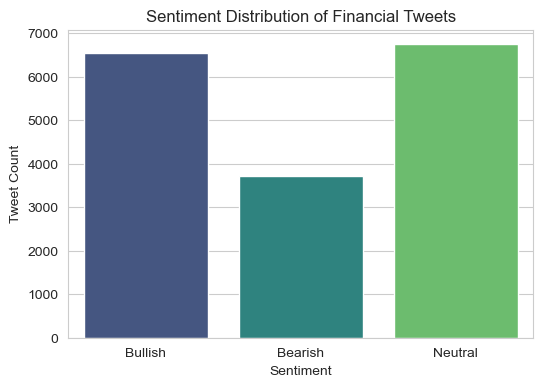

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x=train_df["sentiment"], palette="viridis")

plt.title("Sentiment Distribution of Financial Tweets")
plt.xlabel("Sentiment")
plt.ylabel("Tweet Count")

plt.show()

In [64]:
sample_tweets = [
    "Tesla stock surges after strong earnings report",
    "Oil prices crash due to falling global demand",
    "Federal reserve announces new policy"
]

for tweet in sample_tweets:
    
    sentiment = get_sentiment(tweet)
    
    print("Tweet:", tweet)
    print("Sentiment:", sentiment)
    print()

Tweet: Tesla stock surges after strong earnings report
Sentiment: Bullish

Tweet: Oil prices crash due to falling global demand
Sentiment: Bearish

Tweet: Federal reserve announces new policy
Sentiment: Neutral



# 6.Model Evaluation

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [68]:
#Generate Confusion Matrix
cm = confusion_matrix(y_valid, y_pred)

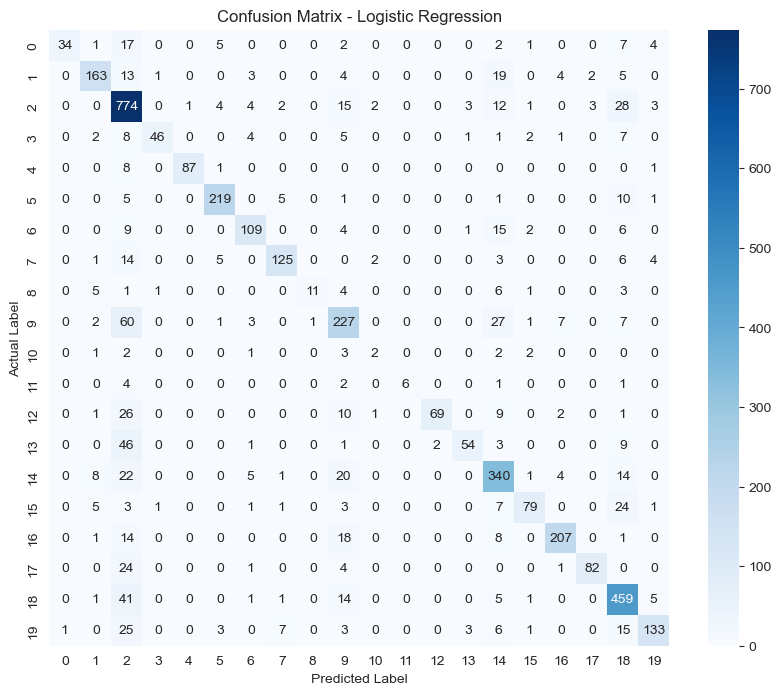

In [70]:
plt.figure(figsize=(10,8))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()


In [71]:
print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.47      0.63        73
           1       0.85      0.76      0.80       214
           2       0.69      0.91      0.79       852
           3       0.94      0.60      0.73        77
           4       0.99      0.90      0.94        97
           5       0.92      0.90      0.91       242
           6       0.82      0.75      0.78       146
           7       0.88      0.78      0.83       160
           8       0.92      0.34      0.50        32
           9       0.67      0.68      0.67       336
          10       0.29      0.15      0.20        13
          11       1.00      0.43      0.60        14
          12       0.97      0.58      0.73       119
          13       0.87      0.47      0.61       116
          14       0.73      0.82      0.77       415
          15       0.86      0.63      0.73       125
          16       0.92      0.83      0.87       249
          17       0.94    

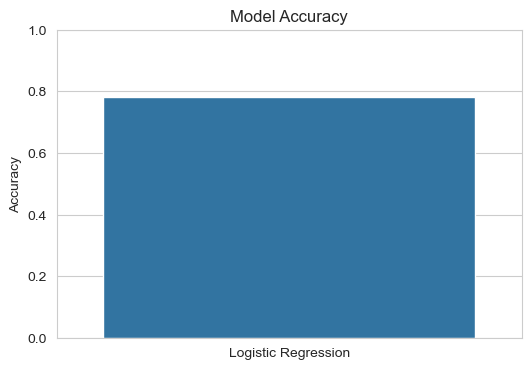

In [72]:
#Accuracy Visualization
models = ["Logistic Regression"]
accuracies = [accuracy]

plt.figure(figsize=(6,4))

sns.barplot(x=models, y=accuracies)

plt.title("Model Accuracy")
plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.show()

# 7.Financial Insights & Interpretation

### 1.Most Discussed Financial Topics

In [73]:
topic_counts = train_df["topic"].value_counts()

print(topic_counts)

topic
Company | Product News         3545
Stock Commentary               2118
Macro                          1822
General News | Opinion         1557
Earnings                        987
Politics                        985
Fed | Central Banks             837
Stock Movement                  823
Financials                      624
Energy | Oil                    524
Markets                         501
Personnel Change                495
Legal | Regulation              487
M&A | Investments               471
Dividend                        359
Treasuries | Corporate Debt     321
Analyst Update                  255
Currencies                      166
Gold | Metals | Materials        69
IPO                              44
Name: count, dtype: int64


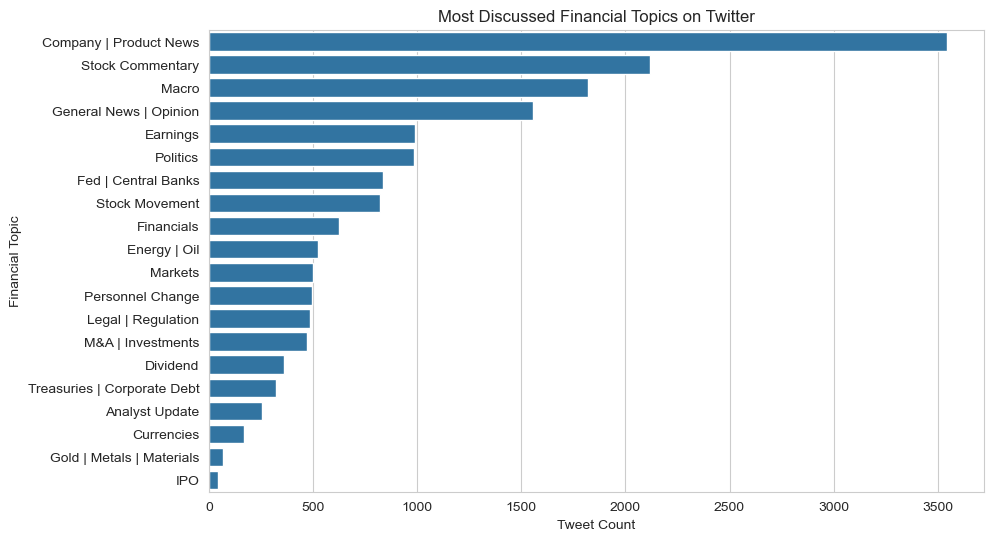

In [74]:
plt.figure(figsize=(10,6))

sns.barplot(x=topic_counts.values, y=topic_counts.index)

plt.title("Most Discussed Financial Topics on Twitter")
plt.xlabel("Tweet Count")
plt.ylabel("Financial Topic")

plt.show()

#### Insight
Company and product related news generates the highest number of financial tweets.

### 2.Overall Market Sentiment Distribution

In [75]:
sentiment_counts = train_df["sentiment"].value_counts()

print(sentiment_counts)

sentiment
Neutral    6742
Bullish    6533
Bearish    3715
Name: count, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_11688\2102057598.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_df["sentiment"], palette="viridis")


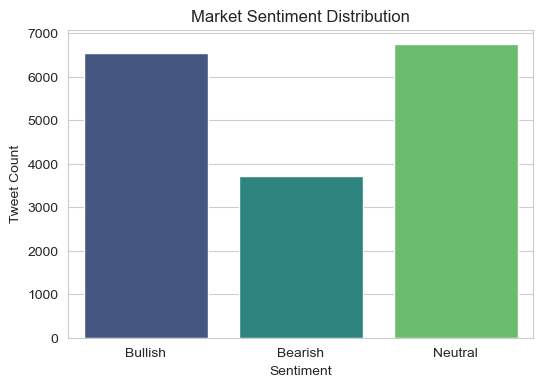

In [77]:
plt.figure(figsize=(6,4))

sns.countplot(x=train_df["sentiment"], palette="viridis")

plt.title("Market Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Tweet Count")

plt.show()

#### Insight
Neutral sentiment dominates financial discussions, indicating that most tweets share informational market updates.

### 3.Sentiment by Financial Topic

In [78]:
topic_sentiment = pd.crosstab(train_df["topic"], train_df["sentiment"])

print(topic_sentiment)


sentiment                    Bearish  Bullish  Neutral
topic                                                 
Analyst Update                    74      105       76
Company | Product News           397     1705     1443
Currencies                        60       42       64
Dividend                          10      111      238
Earnings                          44      140      803
Energy | Oil                     227      196      101
Fed | Central Banks              223      382      232
Financials                       139      197      288
General News | Opinion           630      506      421
Gold | Metals | Materials         25       26       18
IPO                               10       18       16
Legal | Regulation               200      192       95
M&A | Investments                 27      210      234
Macro                            546      618      658
Markets                          140      172      189
Personnel Change                  36      175      284
Politics  

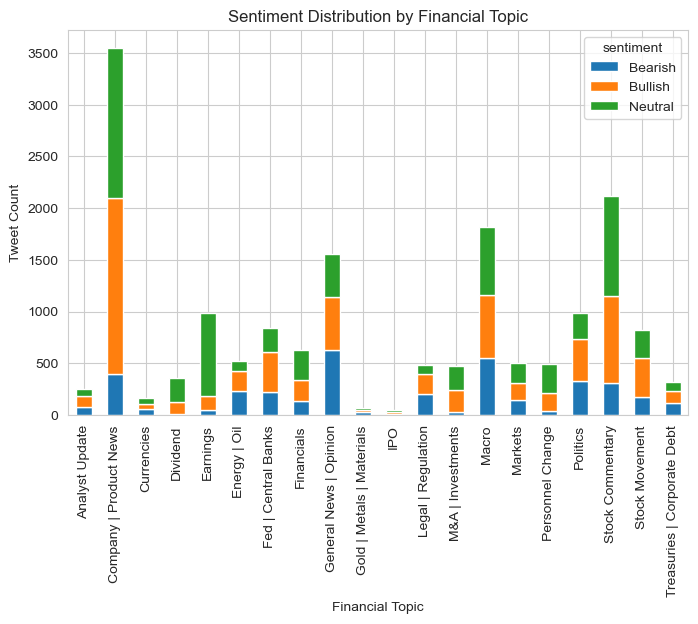

In [107]:
topic_sentiment.plot(kind="bar", stacked=True, figsize=(8,5))

plt.title("Sentiment Distribution by Financial Topic")
plt.xlabel("Financial Topic")
plt.ylabel("Tweet Count")

plt.show()

#### Insight
Earnings announcements often trigger bullish sentiment due to positive company performance news.

### 4.Top 10 Financial Topics
##### Identify the most discussed financial sectors on Twitter.

C:\Users\Admin\AppData\Local\Temp\ipykernel_11688\3114716380.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


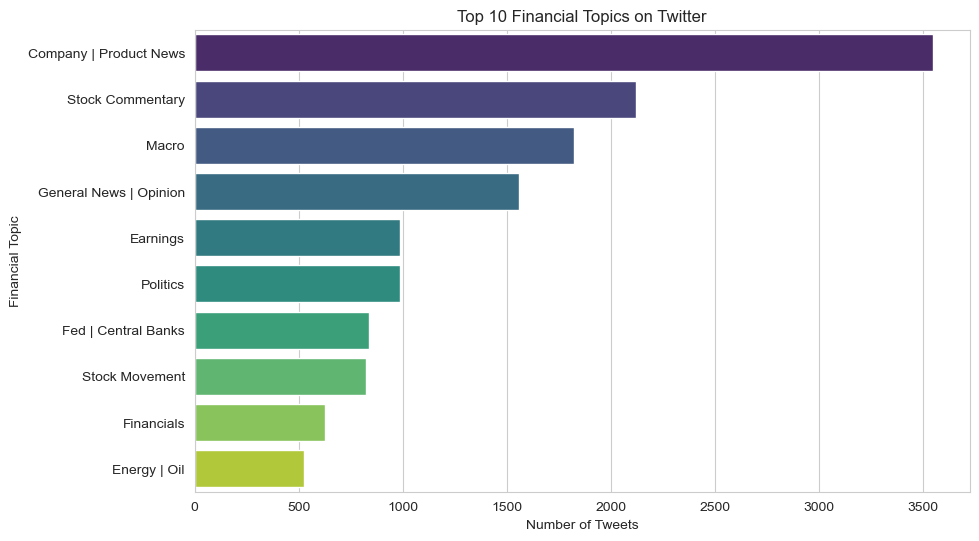

In [80]:
top_topics = train_df["topic"].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_topics.values,
    y=top_topics.index,
    palette="viridis"
)

plt.title("Top 10 Financial Topics on Twitter")
plt.xlabel("Number of Tweets")
plt.ylabel("Financial Topic")

plt.show()

#### Insight
Corporate announcements and Stock Commentary news dominate financial discussions on Twitter.

### 5.Sentiment Distribution
##### Understand overall market mood.

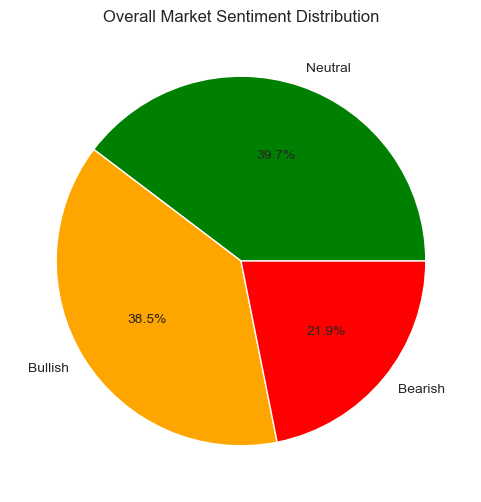

In [83]:
sentiment_counts = train_df["sentiment"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    colors=["green","orange","red"]
)

plt.title("Overall Market Sentiment Distribution")

plt.show()

#### Insight
Most financial tweets share neutral information, while bullish sentiment appears more frequently than bearish sentiment.
Neutral → 39.7%
Bullish → 38.5%
Bearish → 21.9%

### 6. Sentiment vs Topic Heatmap
##### Show which sectors generate positive or negative reactions.

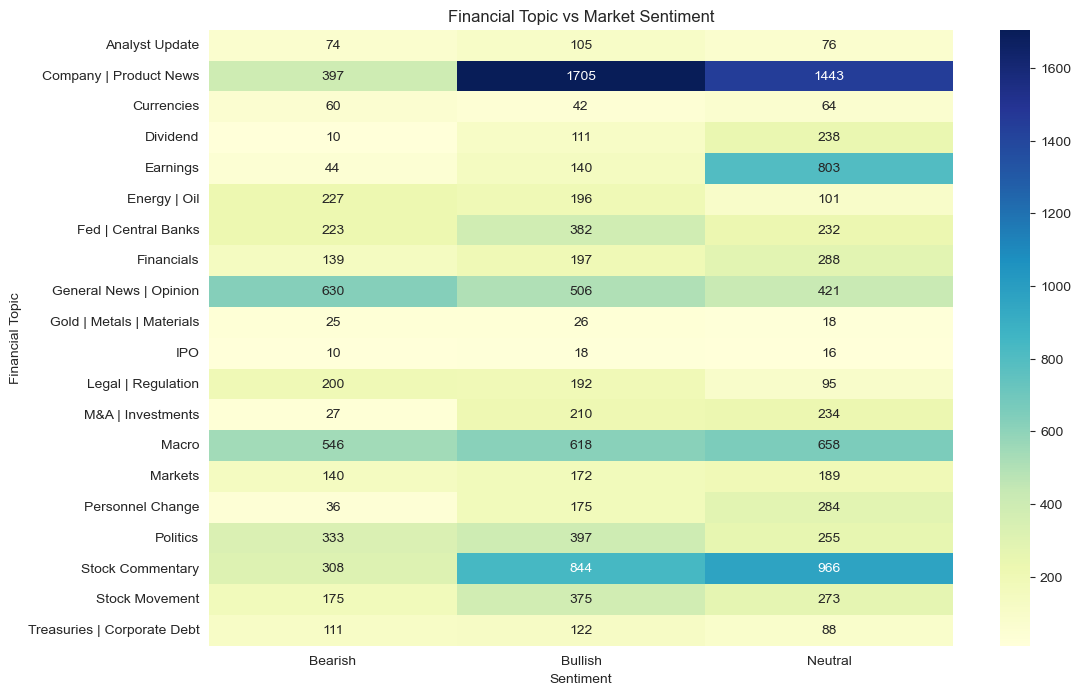

In [98]:
topic_sentiment = pd.crosstab(train_df["topic"], train_df["sentiment"])

plt.figure(figsize=(12,8))

sns.heatmap(topic_sentiment,
            cmap="YlGnBu",
            annot=True,
            fmt="d")

plt.title("Financial Topic vs Market Sentiment")

plt.xlabel("Sentiment")
plt.ylabel("Financial Topic")

plt.show()

#### insight
Company/Product News dominates all sentiment categories, especially Bullish (1,700) and Neutral (1,400), making it the most discussed financial topic by far.
Most topics skew Bullish or Neutral over Bearish, suggesting the dataset reflects an overall optimistic market narrative, with Stock Commentary and Macro also showing notably high neutral-to-bullish activity.

### 7.Tweet Length by Topic
##### Understand information density of tweets.

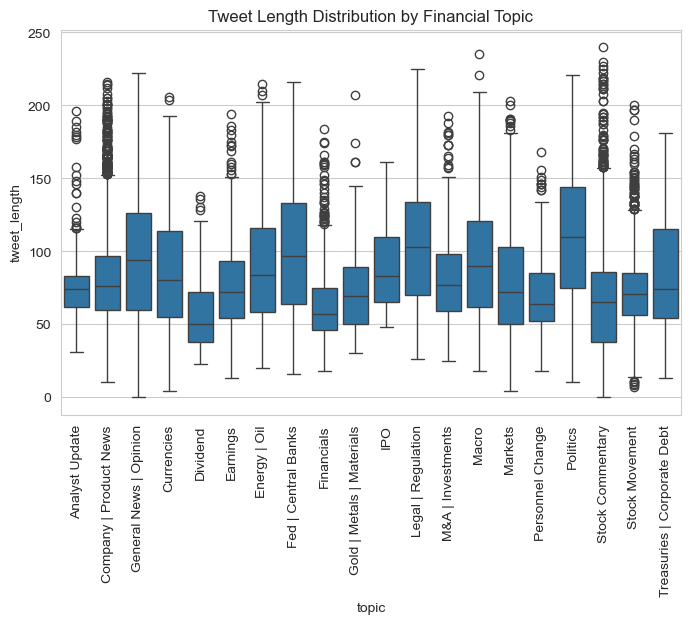

In [86]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="topic",
    y="tweet_length",
    data=train_df
)

plt.xticks(rotation=90)

plt.title("Tweet Length Distribution by Financial Topic")

plt.show()

#### insight
Legal/Regulation and Macro tweets tend to be longer, while Dividend and IPO tweets are notably shorter, suggesting complex topics drive more verbose commentary.

### 8.Word Frequency
#### Identify most important financial keywords

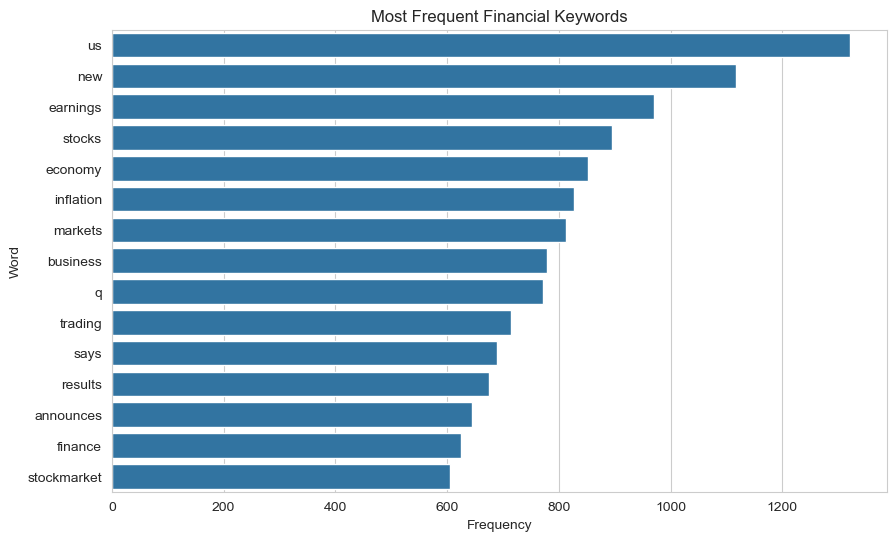

In [87]:
from collections import Counter

all_words = " ".join(train_df["clean_text"])
word_counts = Counter(all_words.split())

top_words = word_counts.most_common(15)

words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

plt.figure(figsize=(10,6))

sns.barplot(x=counts, y=words)

plt.title("Most Frequent Financial Keywords")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

#### insight 
"US," "new," and "earnings" dominate financial Twitter discourse, reflecting a strong focus on domestic market performance and corporate results.

### 9.Tweet Length Distribution
##### Understand typical tweet size.

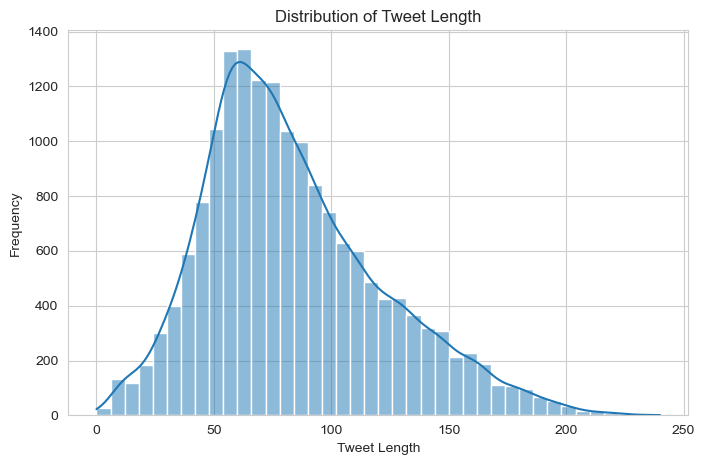

In [89]:
plt.figure(figsize=(8,5))

sns.histplot(
    train_df["tweet_length"],
    bins=40,
    kde=True
)

plt.title("Distribution of Tweet Length")

plt.xlabel("Tweet Length")
plt.ylabel("Frequency")

plt.show()

#### insight
Most tweets cluster between 50–100 characters with a right skew, indicating users prefer concise posts but occasionally write detailed financial commentary.

### 10.Topic Contribution


In [90]:
pip install squarify

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


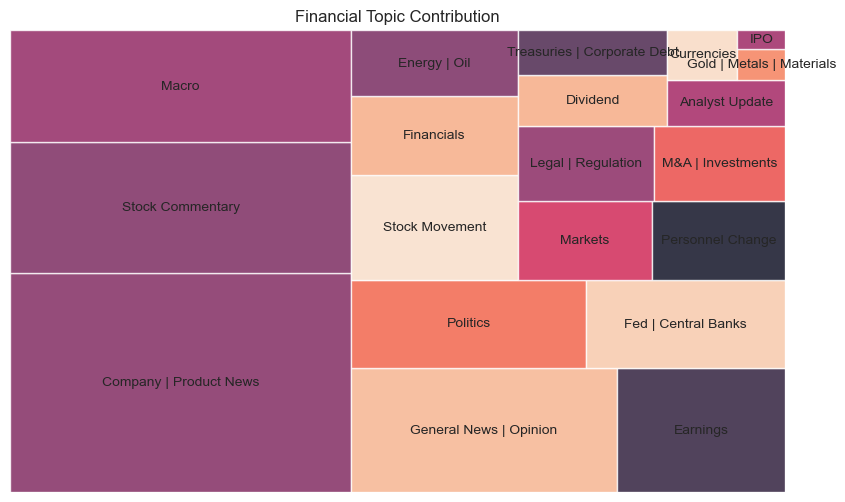

In [91]:
import squarify

sizes = train_df["topic"].value_counts().values
labels = train_df["topic"].value_counts().index

plt.figure(figsize=(10,6))

squarify.plot(
    sizes=sizes,
    label=labels,
    alpha=0.8
)

plt.axis("off")
plt.title("Financial Topic Contribution")

plt.show()

#### insight
Macro, Stock Commentary, and Company/Product News occupy the largest share, confirming these are the core pillars of financial social media conversation.

### 11.Financial Sector Sentiment Radar Chart

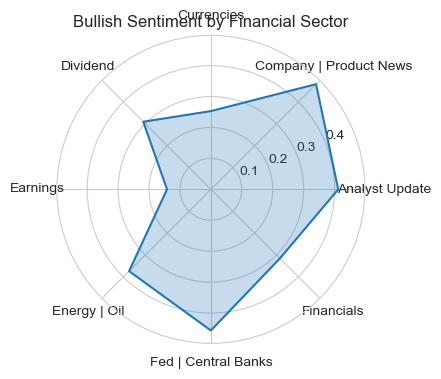

In [96]:
import numpy as np

sector_sentiment = pd.crosstab(train_df["topic"], train_df["sentiment"])

bullish_ratio = sector_sentiment["Bullish"] / sector_sentiment.sum(axis=1)

labels = bullish_ratio.index[:8]
values = bullish_ratio.values[:8]

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)

values = np.concatenate((values,[values[0]]))
angles = np.concatenate((angles,[angles[0]]))

plt.figure(figsize=(4,4))

ax = plt.subplot(111, polar=True)

ax.plot(angles, values)
ax.fill(angles, values, alpha=0.25)

ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)

plt.title("Bullish Sentiment by Financial Sector")

plt.show()

#### insight
Analyst Updates and Company/Product News show the strongest bullish sentiment (~0.4), while Fed/Central Banks scores lowest, reflecting market unease around monetary policy.

### 12.Keyword Network Graph
##### Shows relationships between important financial keywords.

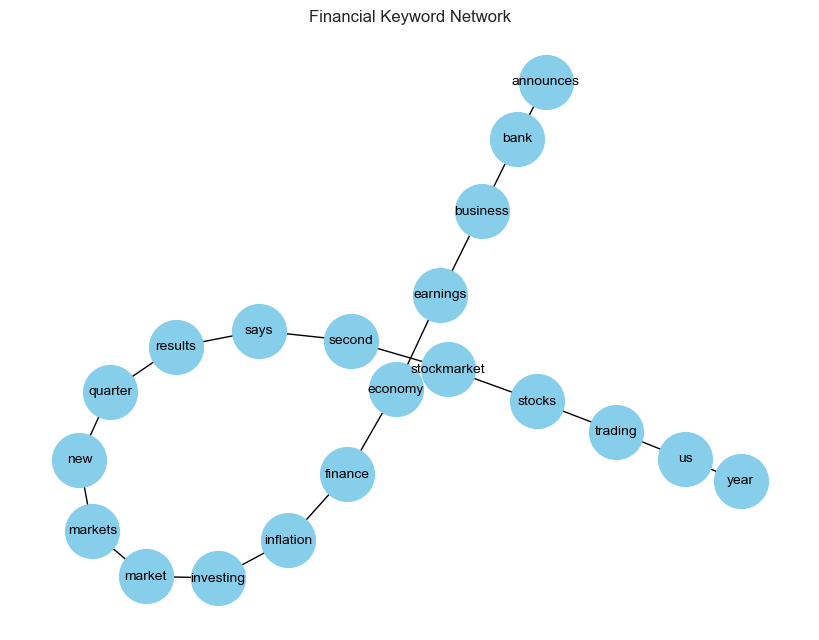

In [104]:
from sklearn.feature_extraction.text import CountVectorizer
import networkx as nx

vectorizer = CountVectorizer(max_features=20)
X = vectorizer.fit_transform(train_df["clean_text"])

words = vectorizer.get_feature_names_out()

G = nx.Graph()

for word in words:
    G.add_node(word)

for i in range(len(words)-1):
    G.add_edge(words[i], words[i+1])

plt.figure(figsize=(8,6))

nx.draw(G,
        with_labels=True,
        node_color="skyblue",
        node_size=1500,
        font_size=10)

plt.title("Financial Keyword Network")

plt.show()

#### insight
"Economy," "stockmarket," and "earnings" act as central hub words, connecting broader themes like inflation, trading, and quarterly results into one interconnected narrative.

### 13.Sentiment vs Tweet Length Analysis
##### Shows if long tweets tend to be bullish or bearish.

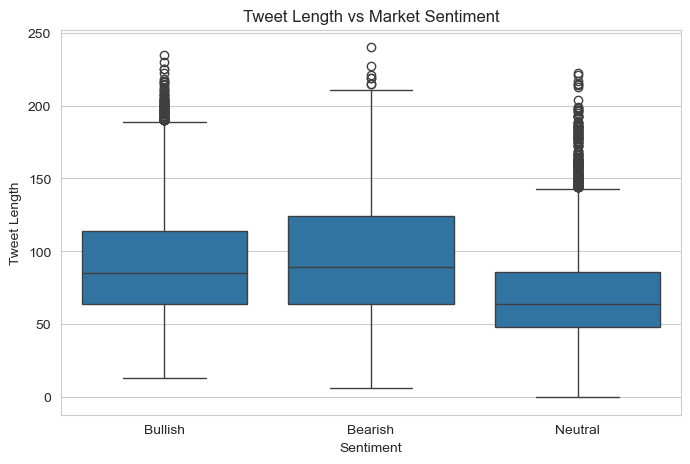

In [105]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="sentiment",
    y="tweet_length",
    data=train_df
)

plt.title("Tweet Length vs Market Sentiment")

plt.xlabel("Sentiment")
plt.ylabel("Tweet Length")

plt.show()

#### insight
Bearish tweets are slightly longer than Bullish or Neutral ones, suggesting users elaborate more when expressing negative market views.

### 14.Top Bullish vs Bearish Topics
##### This compares positive vs negative financial discussions.

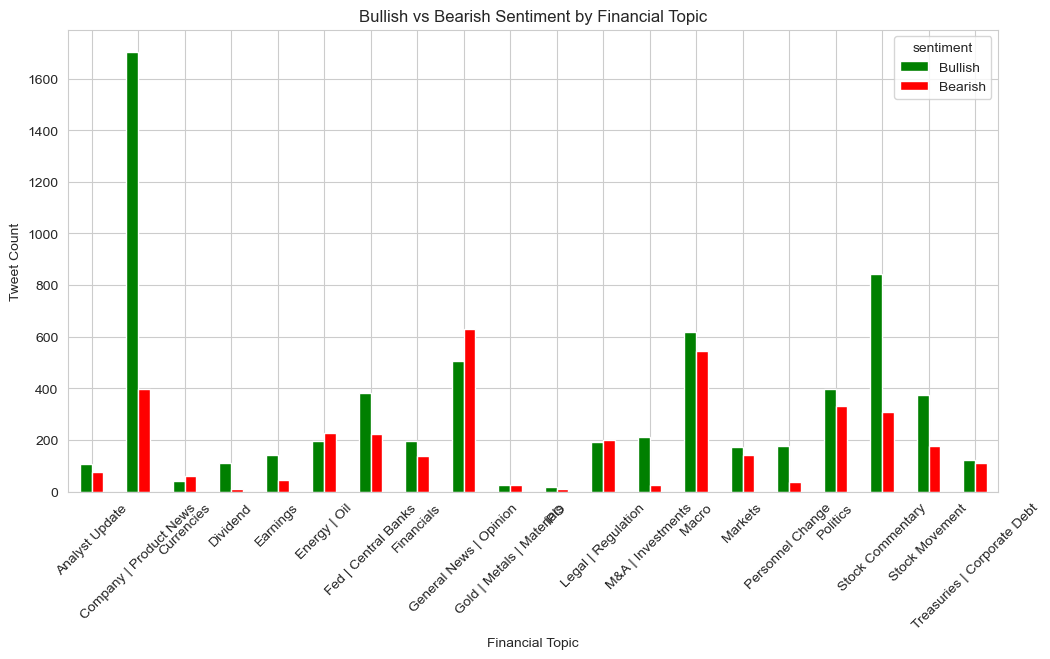

In [106]:
sentiment_topic = pd.crosstab(train_df["topic"], train_df["sentiment"])

sentiment_topic[["Bullish","Bearish"]].plot(
    kind="bar",
    figsize=(12,6),
    color=["green","red"]
)

plt.title("Bullish vs Bearish Sentiment by Financial Topic")

plt.xlabel("Financial Topic")
plt.ylabel("Tweet Count")

plt.xticks(rotation=45)

plt.show()

#### insight
Company/Product News is overwhelmingly bullish (1,700 vs 400), while Financials is the rare topic where bearish sentiment actually edges out bullish — a notable red flag.